In [1]:
%load_ext autoreload
%autoreload 2

In [184]:
from nuscenes import NuScenes

import matplotlib.pyplot as plt
import matplotlib.pyplot as plt
from matplotlib.animation import FFMpegWriter

# Load Data

In [185]:
nusc = NuScenes(version="v1.0-mini", dataroot="../data/nuscenes/")

Loading NuScenes tables for version v1.0-mini...
23 category,
8 attribute,
4 visibility,
911 instance,
12 sensor,
120 calibrated_sensor,
31206 ego_pose,
8 log,
10 scene,
404 sample,
31206 sample_data,
18538 sample_annotation,
4 map,
Done loading in 0.377 seconds.
Reverse indexing ...
Done reverse indexing in 0.1 seconds.


In [186]:
type(nusc)

nuscenes.nuscenes.NuScenes

In [188]:
nusc.table_names

['category',
 'attribute',
 'visibility',
 'instance',
 'sensor',
 'calibrated_sensor',
 'ego_pose',
 'log',
 'scene',
 'sample',
 'sample_data',
 'sample_annotation',
 'map']

In [193]:
nusc.category[0]

{'token': '1fa93b757fc74fb197cdd60001ad8abf',
 'name': 'human.pedestrian.adult',
 'description': 'Adult subcategory.'}

In [194]:
len(nusc.sample)

404

## The Data

That printout is the devkit loading all 13 JSON tables into memory and reporting the row count of each — it's confirming your mini data is intact. Every number there is a count of records in one table. Walking through them, grouped by what they actually describe:

**The taxonomy tables (small, fixed vocabularies):**
- **23 category** — the object classes that *can* be annotated (car, pedestrian, traffic_cone, bicycle, etc.). This is the label vocabulary, later collapsed to the 10 detection classes for the benchmark.
- **8 attribute** — extra state flags on annotations, e.g. `vehicle.parked`, `pedestrian.moving`, `cycle.with_rider`. The mAAE metric scores these.
- **4 visibility** — bins for how much of an object is visible (roughly 0–40%, 40–60%, 60–80%, 80–100%), from the camera views.

**The sensor/calibration tables:**
- **12 sensor** — the physical sensor *types* on the car: 1 LiDAR + 5 radar + 6 cameras = 12. This is the rig definition.
- **120 calibrated_sensor** — one calibration (extrinsics + intrinsics) per sensor *per vehicle/log*. 12 sensors × 10 logs ≈ 120. This is the **sensor→ego** half of your transform chain.

**The pose table:**
- **31206 ego_pose** — the car's global pose (position + orientation) at every sensor timestamp. This is the **ego→global** half of the chain. Note it matches `sample_data` exactly (both 31206) — there's one ego_pose per sensor reading, because the car has moved by the time each sensor fires.

**The structural / scene tables:**
- **8 log** — driving sessions (a log = one continuous recording from one car on one day). Mini draws its 10 scenes from 8 logs.
- **10 scene** — the 10 ~20-second clips that *define* the mini split. This is the number you sanity-check against ("did I get mini?").
- **404 sample** — **keyframes**: the annotated snapshots at 2 Hz. ~40 per scene × 10 ≈ 404. **This is your effective dataset size** — the thing you iterate over. (And why mini can't train a model: 404 samples is nothing.)
- **31206 sample_data** — *every* sensor reading, keyframes **and** the intermediate sweeps between them. Far more than `sample` because between each 2 Hz keyframe, LiDAR/radar/cameras keep firing at their own higher rates. Each row points to one file on disk (a `.pcd.bin`, `.jpg`, etc.).

**The annotation table:**
- **18538 sample_annotation** — individual 3D bounding boxes: one row per object instance per keyframe. ~46 boxes per sample on average. These are your **ground-truth labels**, given in the global frame (which is why Milestone 1 has you transform them into the LiDAR frame).

**The map table:**
- **4 map** — the map masks/layers associated with the logs' locations.

Two relationships worth locking in because they *are* the data model:

- **911 instance** vs **18538 sample_annotation** — an *instance* is one unique physical object (this specific parked car), tracked across the scene; each annotation is that object at one timestamp. So 911 real objects generate 18538 boxes as they're re-annotated frame to frame. Instance is the identity; annotation is the per-frame observation. (This is exactly what tracking tasks exploit.)
- **sample_data = sample + sweeps** — keyframes are the annotated 2 Hz subset; sample_data is the full firehose. You train detection on the keyframes; the sweeps exist for things like multi-sweep LiDAR accumulation.

**"Reverse indexing"** at the end is the devkit precomputing shortcut pointers between tables — e.g. so `sample` can directly list its annotations and sensor readings without you scanning the whole table each time. It's what makes `nusc.get(...)` and the `nusc.field2token` lookups fast. The "0.0 seconds" is just it being trivially quick on mini.

Net read: every table loaded, counts are sensible and internally consistent (10 scenes, 404 keyframes, ego_pose matching sample_data) — your mini split is complete and healthy. You're clear to start the Milestone 1 walk-through.

In [10]:
writer = FFMpegWriter(fps=2) # nuScenes samples keyframes at 2 Hz

fig, ax = plt.subplots(figsize=(12, 8))

# 3. Track your sample sequence across the scene
current_sample_token = my_scene['first_sample_token']
video_path = "./outputs/sample_loop_rendering.mp4"

with writer.saving(fig, video_path, dpi=100):
    while current_sample_token:
        # Get the current sample record
        sample_record = nusc.get('sample', current_sample_token)
        
        # Clear the previous frame axes to prevent memory bloat/overlap
        ax.clear()
        
        # Render directly onto our active figure/axes
        # We pass verbose=False to suppress print statements during the loop
        nusc.render_sample_data(
            sample_record['data']['CAM_FRONT'], 
            ax=ax, 
            verbose=False
        )
        
        # Grab the current frame and write it to the video file
        writer.grab_frame()
        
        # Move to the next sample frame in the sequence
        current_sample_token = sample_record['next']

plt.close(fig)

Compiling frames into video...
Video successfully saved to ./outputs/sample_loop_rendering.mp4!


In [11]:
# Render a summary of the first scene
# nusc.render_scene(
#     my_scene['token'],
#     out_path="./outputs/my_scene_rendering.avi",
# )

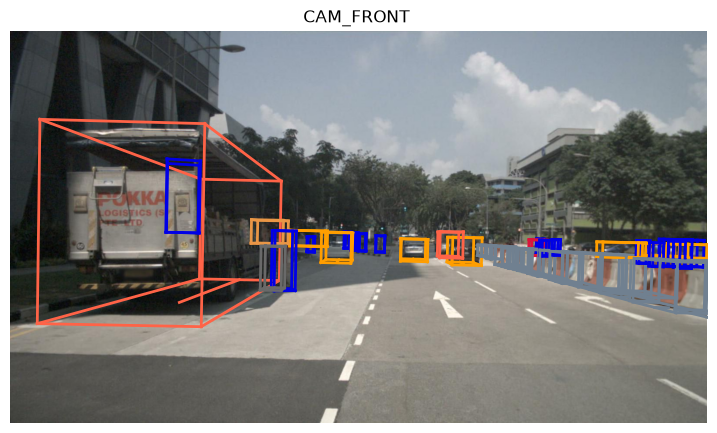

In [12]:
# Render the front camera view with 3D boxes
nusc.render_sample_data(
    nusc.sample[0]["data"]["CAM_FRONT"]
)

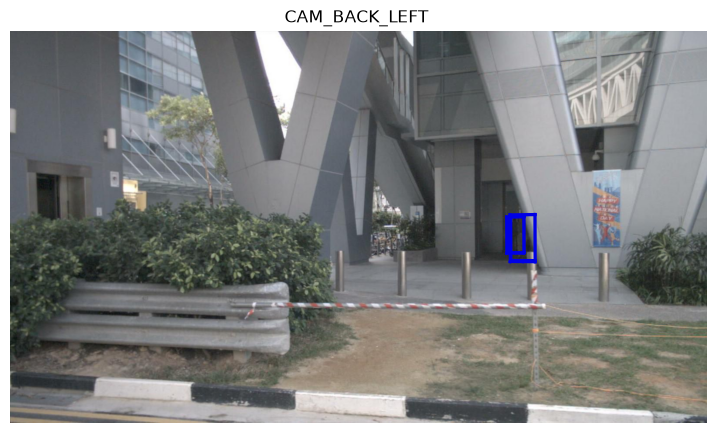

In [13]:
nusc.render_sample_data(
    nusc.sample[0]["data"]["CAM_BACK_LEFT"]
)

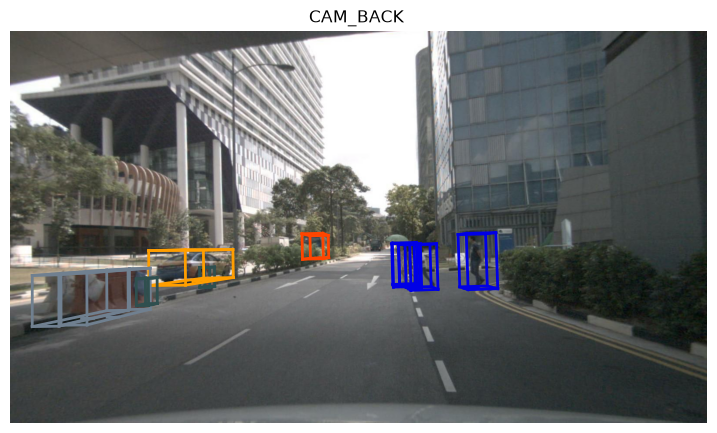

In [14]:
nusc.render_sample_data(
    nusc.sample[0]["data"]["CAM_BACK"]
)

## Walk the chain
- Walk one scene → sample → sample_data chain by hand. Print the tokens at each hop so the relational structure is concrete.

---

- **Scene:** A scene is a continuous, 20-second snippet of a driving sequence captured by the autonomous vehicle.
    - `The Concept`: Think of it like a raw video clip or a single driving log entry.
    - `What it contains`: It doesn't hold sensor data directly. Instead, it provides metadata about the environment (e.g., weather conditions, location like Boston or Singapore, time of day) and points to where the sequence begins and ends using a first_sample_token and a last_sample_token.
<br>

- **Sample:** A sample is a single, time-synchronized snapshot of all sensors at a specific timestamp within a scene.
    - `The Concept`: Think of it as a single multi-modal "frame."
    - `The Frequency`: In nuScenes, samples are generated at a frequency of $2\text{ Hz}$ (one sample every 0.5 seconds). These specific snapshots are chosen because they are the frames that human operators manually annotated with 3D bounding boxes.
    - `What it contains`: It holds a data dictionary containing pointers (tokens) to all the raw sensor outputs captured at that exact millisecond—including all 6 cameras, 1 LiDAR, and 5 Radar sensors.


    - **sample** vs **sample_data**:
        - `sample_data` = The Raw Data Point: <mark>Every single high-frequency image file, LiDAR point cloud, and radar sweep collected by the vehicle gets its own unique entry in the nusc.sample_data table.</mark> So if a camera captures 12 frames in one second, that generates 12 distinct sample_data records.
        - `sample` = The 2 Hz Multi-Sensor Sync Box: A sample record is only created twice a second. It acts as a container that groups together the nearest matching sample_data records from all 12 sensors at that exact millisecond mark.  
    
    - **token** vs **sample_token**:
        - `token` (The File ID)
            - What it is: This is the primary key for the specific piece of sensor data. It uniquely identifies this exact frame (one specific image from CAM_FRONT or one specific point cloud from LIDAR_TOP).
            - Uniqueness: Every single file across the entire 20 Hz / 12 Hz data stream has its own unique token, whether it is a keyframe or an intermediate sweep.
     
        - `sample_token` (The Snapshot Anchor)
            - What it is: This is a foreign key that links this specific piece of sensor data back to the sample table. It tells you which 2 Hz time-synchronized multi-modal snapshot this frame belongs to.
              
            - The Catch for Sweeps: Because intermediate sweeps (is_keyframe=False) happen between the 2 Hz human-annotated marks, they do not align perfectly with a keyframe snapshot. For these raw intermediate frames, the sample_token points to the closest next or previous keyframe sample to maintain a chronological anchor in the database.
<br>

- **Annotation:**
    - `translation`: The absolute $3\text{D}$ position $[x, y, z]$ in meters relative to the global map frame.
    - `size`: The physical dimensions of the object as $[\text{width}, \text{length}, \text{height}]$.
    - `rotation`: The orientation of the bounding box expressed as a quaternion $[w, x, y, z]$.
    - `category_name`: The semantic class label (e.g., vehicle.car, human.pedestrian.adult).
    - `instance_token`: A unique ID tracking this specific object across time. If this same car appears in the next sample frame, it will have a new annotation token, but it will share the exact same instance_token.

---

- **Keyframes** `(is_keyframe=True)`:
    - These are the exact frames synchronized at $2\text{ Hz}$. They are the only ones included in the sample['data'] dictionary, and they are the only ones that have human-annotated 3D bounding boxes (anns).
- **Sweeps** `(is_keyframe=False)`:
    - These are all the intermediate frames captured between the 0.5-second keyframe marks. They do not have human annotations, but they contain the raw, unadulterated LiDAR point clouds and camera images.

> Accumulating Points: In robotics and perception, a single 20 Hz LiDAR sweep can be quite sparse. Engineers frequently use the intermediate "sweeps" (is_keyframe=False) to merge/accumulate multiple consecutive point clouds together using ego-motion tracking. This creates a denser point cloud structure right at the $2\text{ Hz}$ keyframe mark for object detection models to read.


---


- **calibrated_sensor:**
    - The calibrated_sensor table is essentially the vehicle's geometric and optical calibration blueprint. It maps exactly where every sensor is physically mounted on the car and how the raw data should be interpreted. Every raw file in sample_data points to a `calibrated_sensor_token`. Without this table, you cannot project 3D point clouds onto 2D camera images or transform sensor data into a unified coordinate system.
    
    - If you grab a record from nusc.calibrated_sensor, it contains two core types of information: Extrinsics and Intrinsics.
 
        1. **Sensor Extrinsics (Spatial Calibration):**
            - `translation ($[x, y, z]$ in meters):` The exact physical position of the sensor **relative to the ego vehicle coordinate frame (the origin is typically the center of the rear axle)**.
            - `rotation ($[w, x, y, z]$ as a quaternion):` The exact angular orientation of the sensor **relative to the vehicle frame**.
            - Why it matters: This tells your code, for example, that CAM_FRONT is mounted 1.5 meters off the ground and tilted 2 degrees downward. You use this to transform points from a specific sensor's frame into the vehicle's shared coordinate space.
      
        2. **Sensor Intrinsics (Optical Calibration — Cameras Only)**
            - `camera_intrinsic (A $3 \times 3$ matrix):` This matrix contains the focal lengths ($f_x, f_y$) and the principal point ($c_x, c_y$) in pixels.
            - Why it matters: This describes the camera's internal geometry (how light bends through the lens). You need this matrix to project $3\text{D}$ world points (like a LiDAR point or a 3D bounding box corner) directly onto a camera's $2\text{D}$ image plane so they line up perfectly on your screen.
<br>

- In nuScenes dataset there are `12 sensors` and `120 calibrated_sensors`, why?
    - calibration changes across different driving logs or collection sessions.
 
    - Over months of data collection, a sensor might be unmounted for maintenance, a camera lens might be replaced, or subtle shifts can happen to the physical mounts on the roof. Because of this the calibrated_sensor table creates a unique entry for every specific setup used in a given driving log.
 
    - **When you look up a sample_data record, its calibrated_sensor_token guides you to the exact extrinsic and intrinsic matrices that were valid at the moment that specific log was recorded**
 

---

- **ego_pose:**
    
    - `ego_pose` represents the absolute physical position and orientation of the autonomous vehicle itself at a specific time. It tells you where the car is physically located relative to the global map (a place in the city).
    
    - What it contains:
        - `translation ($[x, y, z]$ in meters)`: The $3\text{D}$ coordinate of the vehicle's center (usually the midpoint of the rear axle) relative to the global coordinate origin of the map city (e.g., Boston or Singapore).
        - `rotation ($[w, x, y, z]$ as a quaternion)`: The exact heading, pitch, and roll of the vehicle chassis relative to the global map.
    
    - **Where does it come from?**
        - It is produced by an **Applanix POS LV** system.
        - It is an integrated **INS (Inertial Navigation System)**.
        - It combines the raw **IMU** data with high-grade multi-frequency **GPS/GNSS** receivers and a **wheel-odometry DMI (Distance Measurement Indicator)**.
        - The outputs are passed through a post-processed **Kalman filter** to generate a highly accurate, smoothed localization track ($3\text{D}$ position and orientation) 
    
    - It matches the size of `sample_data`. Because every single raw sensor reading needs to know exactly where the car was when that data point was captured.
        - They do not all publish at the exact same time.
        - `ego_pose` is calculated at a high frequency ($100\text{ Hz}$), and the devkit interpolates the vehicle's position to match the exact timestamp of each sensor.
    
    - **Vehicles reference frame**:
        - `$+X$ Axis`: Points out the **right** side of the vehicle.
        - `$+Y$ Axis`: Points straight **forward** along the direction of travel.
        - `$+Z$ Axis`: Points straight **up** into the air.
    
    - **Global reference frame**:
        - It is a fixed point in the city map coordinate system. This origin is a static, unchanging geographic point anchoring the digital HD map.
        
        - **To place a point from a raw sensor file into the world, you chain these frames together:**
            $$\text{Sensor Frame} \xrightarrow{\text{calibrated\_sensor}} \text{Ego Vehicle Frame} \xrightarrow{\text{ego\_pose}} \text{Global City Frame}$$
     

---

- **log**
    - In nuScenes, the log table contains metadata about the specific data collection session (or driving route) during which the raw data was recorded.
    - If a scene is a 20-second clip, a log represents the entire continuous driving shift—often lasting hours—from which many individual 20-second clips were extracted.

---

- **map**
    - In nuScenes, the map table handles the environmental spatial context. It stores the binary mask layers and semantic metadata for the high-definition (HD) maps of the cities where the data collection vehicles operated. Instead of treating a driving environment as a raw, empty 3D grid, the map table allows you to overlay the vehicle's position and sensor points onto structured, real-world road geometry.
    
    - `semantic_prior`: High-Definition (HD) background maps.
        
        - It means that the map file is stored as a **top-down**, **bird's-eye-view** **binary semantic mask** layout.
        
        - It is called a "prior" because it gives a perception or motion-planning model static, pre-existing structural knowledge about the static layout of the world before the vehicle even processes its live camera or LiDAR frames.  In the standard nuScenes dataset, this category represents two key environmental layers:  Drivable Surface: A binary mask showing exactly where cars are physically allowed to drive (the asphalt lanes, intersections, etc.).  Sidewalk: A binary mask showing exactly where pedestrian walkways are located.
     
        - semantic_prior represents two key environmental layers
     
            1. `Drivable Surface`: A binary mask showing exactly where cars are physically allowed to drive (the asphalt lanes, intersections, etc.).
            2. `Sidewalk`: A binary mask showing exactly where pedestrian walkways are located.

---

- **token**
    
    - In nuScenes, a token is a universally unique identifier (UUID)—specifically a 32-character hexadecimal string—that acts as a primary database key.
    
    - It serves as an immutable ID for a specific record so that any other table or object in the dataset can find it, reference it, and link directly to it.
 
    
    - Token properties:

        1. Global Uniqueness: A token like ca9a282c9e77460f8360f564131a8af5 is completely unique across the entire dataset. No two images, bounding boxes, or scenes anywhere in the world will ever share the same token.
        
        2. Independent Linking: It allows tables to form a relational **network (a graph)**. For example, a sample record **doesn't need to hold raw camera files**; it just lists a **CAM_FRONT token**. When your code needs the actual image metadata, it hands that token over to **nusc.get('sample_data', token) to fetch it**.
     
        3. **Linked List** Navigation: Tokens are what allow you to traverse time frame-by-frame. Every sample data or sample record contains a **next** and **prev** key whose values are simply the tokens of the adjacent chronological frames.
     

---

- **Some points**
    
    - The first_sample_token in a scene is the token for the first sample in that scene, not the sample_data.
    
    - A sample is never a sample_data. They are two completely separate, distinct concepts and tables in the nuScenes schema.
 
        - `sample (The Box)`: This is purely a synchronized time-container. It does not represent a physical file on disk. It is a dictionary that groups together all the raw data points from all 12 sensors that happened to fire at that exact 0.5-second mark.
        
        - `sample_data (The Items Inside)`: This represents an actual physical file—a single .jpg image from a camera or a single .pcd.bin point cloud file from the LiDAR.
     
        - **Usecase**
 
            - You query a sample when you want to look at the **ground-truth annotations**.
        
            - You query a sample_data when you want the actual physical **file path (filename)** to load an image matrix or a LiDAR point cloud into memory.
         

- **How to get the closest LiDAR data from an image sample_data**:

    1. Grab the timestamp of your camera sample_data.
    
    2. Step into the sample_data table and filter for sensor_channel == 'LIDAR_TOP'.
 
    3. Search the timeline (using the next and prev tokens of the LiDAR stream) to find the specific LiDAR frame whose timestamp has the absolute smallest delta from your camera timestamp.
 

- **Training only happens on samples, not sample_data**

    - You can't train detection on an intermediate sample_data because it has no annotations. Boxes exist only at keyframes (samples). So a non-keyframe LiDAR sweep has no ground truth to supervise against — it can't be a row in your dataset.
 
    - A single LiDAR sweep is sparse (one rotation of a 32-beam sensor — not many points per object, especially far away). To densify, you take the keyframe's LiDAR plus the several intermediate LiDAR sweeps just before it, motion-compensate them (transform each into the keyframe's frame using the ego-poses, since the car moved between sweeps), and stack them into one denser point cloud. That accumulated cloud is what actually feeds the model.

In [7]:
nusc.sample_data[0]

{'token': '5ace90b379af485b9dcb1584b01e7212',
 'sample_token': '39586f9d59004284a7114a68825e8eec',
 'ego_pose_token': '5ace90b379af485b9dcb1584b01e7212',
 'calibrated_sensor_token': 'f4d2a6c281f34a7eb8bb033d82321f79',
 'timestamp': 1532402927814384,
 'fileformat': 'pcd',
 'is_key_frame': False,
 'height': 0,
 'width': 0,
 'filename': 'sweeps/RADAR_FRONT/n015-2018-07-24-11-22-45+0800__RADAR_FRONT__1532402927814384.pcd',
 'prev': 'f0b8593e08594a3eb1152c138b312813',
 'next': '978db2bcdf584b799c13594a348576d2',
 'sensor_modality': 'radar',
 'channel': 'RADAR_FRONT'}

In [8]:
nusc.sample[0]

{'token': 'ca9a282c9e77460f8360f564131a8af5',
 'timestamp': 1532402927647951,
 'prev': '',
 'next': '39586f9d59004284a7114a68825e8eec',
 'scene_token': 'cc8c0bf57f984915a77078b10eb33198',
 'data': {'RADAR_FRONT': '37091c75b9704e0daa829ba56dfa0906',
  'RADAR_FRONT_LEFT': '11946c1461d14016a322916157da3c7d',
  'RADAR_FRONT_RIGHT': '491209956ee3435a9ec173dad3aaf58b',
  'RADAR_BACK_LEFT': '312aa38d0e3e4f01b3124c523e6f9776',
  'RADAR_BACK_RIGHT': '07b30d5eb6104e79be58eadf94382bc1',
  'LIDAR_TOP': '9d9bf11fb0e144c8b446d54a8a00184f',
  'CAM_FRONT': 'e3d495d4ac534d54b321f50006683844',
  'CAM_FRONT_RIGHT': 'aac7867ebf4f446395d29fbd60b63b3b',
  'CAM_BACK_RIGHT': '79dbb4460a6b40f49f9c150cb118247e',
  'CAM_BACK': '03bea5763f0f4722933508d5999c5fd8',
  'CAM_BACK_LEFT': '43893a033f9c46d4a51b5e08a67a1eb7',
  'CAM_FRONT_LEFT': 'fe5422747a7d4268a4b07fc396707b23'},
 'anns': ['ef63a697930c4b20a6b9791f423351da',
  '6b89da9bf1f84fd6a5fbe1c3b236f809',
  '924ee6ac1fed440a9d9e3720aac635a0',
  '91e3608f55174a319

In [9]:
nusc.table_names

['category',
 'attribute',
 'visibility',
 'instance',
 'sensor',
 'calibrated_sensor',
 'ego_pose',
 'log',
 'scene',
 'sample',
 'sample_data',
 'sample_annotation',
 'map']

In [10]:
# List all the main tables and their sizes
nusc.list_attributes()

cycle.with_rider: 305
cycle.without_rider: 434
pedestrian.moving: 3875
pedestrian.sitting_lying_down: 111
pedestrian.standing: 1029
vehicle.moving: 2715
vehicle.parked: 4674
vehicle.stopped: 1545


In [11]:
nusc.list_scenes()

scene-0061, Parked truck, construction, intersectio... [18-07-24 03:28:47]   19s, singapore-onenorth, #anns:4622
scene-0103, Many peds right, wait for turning car, ... [18-08-01 19:26:43]   19s, boston-seaport, #anns:2046
scene-0655, Parking lot, parked cars, jaywalker, be... [18-08-27 15:51:32]   20s, boston-seaport, #anns:2332
scene-0553, Wait at intersection, bicycle, large tr... [18-08-28 20:48:16]   20s, boston-seaport, #anns:1950
scene-0757, Arrive at busy intersection, bus, wait ... [18-08-30 19:25:08]   20s, boston-seaport, #anns:592
scene-0796, Scooter, peds on sidewalk, bus, cars, t... [18-10-02 02:52:24]   20s, singapore-queensto, #anns:708
scene-0916, Parking lot, bicycle rack, parked bicyc... [18-10-08 07:37:13]   20s, singapore-queensto, #anns:2387
scene-1077, Night, big street, bus stop, high speed... [18-11-21 11:39:27]   20s, singapore-hollandv, #anns:890
scene-1094, Night, after rain, many peds, PMD, ped ... [18-11-21 11:47:27]   19s, singapore-hollandv, #anns:1762
sc

In [12]:
# Grab the first scene record
scene_record = nusc.scene[0]
scene_record

{'token': 'cc8c0bf57f984915a77078b10eb33198',
 'log_token': '7e25a2c8ea1f41c5b0da1e69ecfa71a2',
 'nbr_samples': 39,
 'first_sample_token': 'ca9a282c9e77460f8360f564131a8af5',
 'last_sample_token': 'ed5fc18c31904f96a8f0dbb99ff069c0',
 'name': 'scene-0061',
 'description': 'Parked truck, construction, intersection, turn left, following a van'}

In [13]:
sample_record = nusc.sample[0]
sample_record

{'token': 'ca9a282c9e77460f8360f564131a8af5',
 'timestamp': 1532402927647951,
 'prev': '',
 'next': '39586f9d59004284a7114a68825e8eec',
 'scene_token': 'cc8c0bf57f984915a77078b10eb33198',
 'data': {'RADAR_FRONT': '37091c75b9704e0daa829ba56dfa0906',
  'RADAR_FRONT_LEFT': '11946c1461d14016a322916157da3c7d',
  'RADAR_FRONT_RIGHT': '491209956ee3435a9ec173dad3aaf58b',
  'RADAR_BACK_LEFT': '312aa38d0e3e4f01b3124c523e6f9776',
  'RADAR_BACK_RIGHT': '07b30d5eb6104e79be58eadf94382bc1',
  'LIDAR_TOP': '9d9bf11fb0e144c8b446d54a8a00184f',
  'CAM_FRONT': 'e3d495d4ac534d54b321f50006683844',
  'CAM_FRONT_RIGHT': 'aac7867ebf4f446395d29fbd60b63b3b',
  'CAM_BACK_RIGHT': '79dbb4460a6b40f49f9c150cb118247e',
  'CAM_BACK': '03bea5763f0f4722933508d5999c5fd8',
  'CAM_BACK_LEFT': '43893a033f9c46d4a51b5e08a67a1eb7',
  'CAM_FRONT_LEFT': 'fe5422747a7d4268a4b07fc396707b23'},
 'anns': ['ef63a697930c4b20a6b9791f423351da',
  '6b89da9bf1f84fd6a5fbe1c3b236f809',
  '924ee6ac1fed440a9d9e3720aac635a0',
  '91e3608f55174a319

In [14]:
sample_record["anns"][0]

'ef63a697930c4b20a6b9791f423351da'

In [15]:
nusc.get("sample_annotation", sample_record["anns"][0])

{'token': 'ef63a697930c4b20a6b9791f423351da',
 'sample_token': 'ca9a282c9e77460f8360f564131a8af5',
 'instance_token': '6dd2cbf4c24b4caeb625035869bca7b5',
 'visibility_token': '1',
 'attribute_tokens': ['4d8821270b4a47e3a8a300cbec48188e'],
 'translation': [373.256, 1130.419, 0.8],
 'size': [0.621, 0.669, 1.642],
 'rotation': [0.9831098797903927, 0.0, 0.0, -0.18301629506281616],
 'prev': '',
 'next': '7987617983634b119e383d8a29607fd7',
 'num_lidar_pts': 1,
 'num_radar_pts': 0,
 'category_name': 'human.pedestrian.adult'}

In [16]:
first_sample_token = scene_record["first_sample_token"]
nusc.list_sample(first_sample_token)

Sample: ca9a282c9e77460f8360f564131a8af5

sample_data_token: 37091c75b9704e0daa829ba56dfa0906, mod: radar, channel: RADAR_FRONT
sample_data_token: 11946c1461d14016a322916157da3c7d, mod: radar, channel: RADAR_FRONT_LEFT
sample_data_token: 491209956ee3435a9ec173dad3aaf58b, mod: radar, channel: RADAR_FRONT_RIGHT
sample_data_token: 312aa38d0e3e4f01b3124c523e6f9776, mod: radar, channel: RADAR_BACK_LEFT
sample_data_token: 07b30d5eb6104e79be58eadf94382bc1, mod: radar, channel: RADAR_BACK_RIGHT
sample_data_token: 9d9bf11fb0e144c8b446d54a8a00184f, mod: lidar, channel: LIDAR_TOP
sample_data_token: e3d495d4ac534d54b321f50006683844, mod: camera, channel: CAM_FRONT
sample_data_token: aac7867ebf4f446395d29fbd60b63b3b, mod: camera, channel: CAM_FRONT_RIGHT
sample_data_token: 79dbb4460a6b40f49f9c150cb118247e, mod: camera, channel: CAM_BACK_RIGHT
sample_data_token: 03bea5763f0f4722933508d5999c5fd8, mod: camera, channel: CAM_BACK
sample_data_token: 43893a033f9c46d4a51b5e08a67a1eb7, mod: camera, channel:

In [17]:
# 2. Hop into the very first sample (the 2 Hz keyframe container)
first_sample_token = scene_record["first_sample_token"]
sample_record = nusc.get("sample", first_sample_token)
sample_record

{'token': 'ca9a282c9e77460f8360f564131a8af5',
 'timestamp': 1532402927647951,
 'prev': '',
 'next': '39586f9d59004284a7114a68825e8eec',
 'scene_token': 'cc8c0bf57f984915a77078b10eb33198',
 'data': {'RADAR_FRONT': '37091c75b9704e0daa829ba56dfa0906',
  'RADAR_FRONT_LEFT': '11946c1461d14016a322916157da3c7d',
  'RADAR_FRONT_RIGHT': '491209956ee3435a9ec173dad3aaf58b',
  'RADAR_BACK_LEFT': '312aa38d0e3e4f01b3124c523e6f9776',
  'RADAR_BACK_RIGHT': '07b30d5eb6104e79be58eadf94382bc1',
  'LIDAR_TOP': '9d9bf11fb0e144c8b446d54a8a00184f',
  'CAM_FRONT': 'e3d495d4ac534d54b321f50006683844',
  'CAM_FRONT_RIGHT': 'aac7867ebf4f446395d29fbd60b63b3b',
  'CAM_BACK_RIGHT': '79dbb4460a6b40f49f9c150cb118247e',
  'CAM_BACK': '03bea5763f0f4722933508d5999c5fd8',
  'CAM_BACK_LEFT': '43893a033f9c46d4a51b5e08a67a1eb7',
  'CAM_FRONT_LEFT': 'fe5422747a7d4268a4b07fc396707b23'},
 'anns': ['ef63a697930c4b20a6b9791f423351da',
  '6b89da9bf1f84fd6a5fbe1c3b236f809',
  '924ee6ac1fed440a9d9e3720aac635a0',
  '91e3608f55174a319

In [18]:
# 3. Hop into specific Sample Data tracks (the raw files)
cam_front_token = sample_record["data"]["CAM_FRONT"]
lidar_top_token = sample_record["data"]["LIDAR_TOP"]

In [19]:
cam_data_record = nusc.get("sample_data", cam_front_token)
lidar_data_record = nusc.get("sample_data", lidar_top_token)

In [20]:
cam_data_record

{'token': 'e3d495d4ac534d54b321f50006683844',
 'sample_token': 'ca9a282c9e77460f8360f564131a8af5',
 'ego_pose_token': 'e3d495d4ac534d54b321f50006683844',
 'calibrated_sensor_token': '1d31c729b073425e8e0202c5c6e66ee1',
 'timestamp': 1532402927612460,
 'fileformat': 'jpg',
 'is_key_frame': True,
 'height': 900,
 'width': 1600,
 'filename': 'samples/CAM_FRONT/n015-2018-07-24-11-22-45+0800__CAM_FRONT__1532402927612460.jpg',
 'prev': '',
 'next': '68e8e98cf7b0487baa139df808641db7',
 'sensor_modality': 'camera',
 'channel': 'CAM_FRONT'}

In [21]:
lidar_data_record

{'token': '9d9bf11fb0e144c8b446d54a8a00184f',
 'sample_token': 'ca9a282c9e77460f8360f564131a8af5',
 'ego_pose_token': '9d9bf11fb0e144c8b446d54a8a00184f',
 'calibrated_sensor_token': 'a183049901c24361a6b0b11b8013137c',
 'timestamp': 1532402927647951,
 'fileformat': 'pcd',
 'is_key_frame': True,
 'height': 0,
 'width': 0,
 'filename': 'samples/LIDAR_TOP/n015-2018-07-24-11-22-45+0800__LIDAR_TOP__1532402927647951.pcd.bin',
 'prev': '',
 'next': '0cedf1d2d652468d92d23491136b5d15',
 'sensor_modality': 'lidar',
 'channel': 'LIDAR_TOP'}

In [22]:
nusc.table_names

['category',
 'attribute',
 'visibility',
 'instance',
 'sensor',
 'calibrated_sensor',
 'ego_pose',
 'log',
 'scene',
 'sample',
 'sample_data',
 'sample_annotation',
 'map']

In [23]:
type(nusc.sample_data), len(nusc.sample_data), nusc.sample_data[0]

(list,
 31206,
 {'token': '5ace90b379af485b9dcb1584b01e7212',
  'sample_token': '39586f9d59004284a7114a68825e8eec',
  'ego_pose_token': '5ace90b379af485b9dcb1584b01e7212',
  'calibrated_sensor_token': 'f4d2a6c281f34a7eb8bb033d82321f79',
  'timestamp': 1532402927814384,
  'fileformat': 'pcd',
  'is_key_frame': False,
  'height': 0,
  'width': 0,
  'filename': 'sweeps/RADAR_FRONT/n015-2018-07-24-11-22-45+0800__RADAR_FRONT__1532402927814384.pcd',
  'prev': 'f0b8593e08594a3eb1152c138b312813',
  'next': '978db2bcdf584b799c13594a348576d2',
  'sensor_modality': 'radar',
  'channel': 'RADAR_FRONT'})

In [24]:
nusc.get("sample_data", nusc.sample_data[0]["token"]) ==  nusc.sample_data[0]

True

In [25]:
type(nusc.sample), len(nusc.sample), nusc.sample[0]

(list,
 404,
 {'token': 'ca9a282c9e77460f8360f564131a8af5',
  'timestamp': 1532402927647951,
  'prev': '',
  'next': '39586f9d59004284a7114a68825e8eec',
  'scene_token': 'cc8c0bf57f984915a77078b10eb33198',
  'data': {'RADAR_FRONT': '37091c75b9704e0daa829ba56dfa0906',
   'RADAR_FRONT_LEFT': '11946c1461d14016a322916157da3c7d',
   'RADAR_FRONT_RIGHT': '491209956ee3435a9ec173dad3aaf58b',
   'RADAR_BACK_LEFT': '312aa38d0e3e4f01b3124c523e6f9776',
   'RADAR_BACK_RIGHT': '07b30d5eb6104e79be58eadf94382bc1',
   'LIDAR_TOP': '9d9bf11fb0e144c8b446d54a8a00184f',
   'CAM_FRONT': 'e3d495d4ac534d54b321f50006683844',
   'CAM_FRONT_RIGHT': 'aac7867ebf4f446395d29fbd60b63b3b',
   'CAM_BACK_RIGHT': '79dbb4460a6b40f49f9c150cb118247e',
   'CAM_BACK': '03bea5763f0f4722933508d5999c5fd8',
   'CAM_BACK_LEFT': '43893a033f9c46d4a51b5e08a67a1eb7',
   'CAM_FRONT_LEFT': 'fe5422747a7d4268a4b07fc396707b23'},
  'anns': ['ef63a697930c4b20a6b9791f423351da',
   '6b89da9bf1f84fd6a5fbe1c3b236f809',
   '924ee6ac1fed440a9d9e37

In [26]:
current_lidar_token = nusc.sample[0]["data"]["LIDAR_TOP"]
lidar_data = nusc.get('sample_data', current_lidar_token)

lidar_data

{'token': '9d9bf11fb0e144c8b446d54a8a00184f',
 'sample_token': 'ca9a282c9e77460f8360f564131a8af5',
 'ego_pose_token': '9d9bf11fb0e144c8b446d54a8a00184f',
 'calibrated_sensor_token': 'a183049901c24361a6b0b11b8013137c',
 'timestamp': 1532402927647951,
 'fileformat': 'pcd',
 'is_key_frame': True,
 'height': 0,
 'width': 0,
 'filename': 'samples/LIDAR_TOP/n015-2018-07-24-11-22-45+0800__LIDAR_TOP__1532402927647951.pcd.bin',
 'prev': '',
 'next': '0cedf1d2d652468d92d23491136b5d15',
 'sensor_modality': 'lidar',
 'channel': 'LIDAR_TOP'}

In [77]:
# Start with the keyframe LiDAR token from your sample
current_lidar_token = nusc.sample[0]["data"]["LIDAR_TOP"]

# Traverse through the raw 20 Hz sweep frames
for i in range(5):  # Let's look at the next 5 intermediate sweeps
    lidar_data = nusc.get("sample_data", current_lidar_token)
    
    print(f"Frame {i}: Token={lidar_data["token"]} | "
          f"Timestamp={lidar_data["timestamp"]} | "
          f"Is Keyframe={lidar_data["is_key_frame"]}")
    
    # Move to the absolute next raw chronological frame (approx. 0.05s later for LiDAR)
    current_lidar_token = lidar_data["next"]
    if not current_lidar_token:
        break

Frame 0: Token=9d9bf11fb0e144c8b446d54a8a00184f | Timestamp=1532402927647951 | Is Keyframe=True
Frame 1: Token=0cedf1d2d652468d92d23491136b5d15 | Timestamp=1532402927697752 | Is Keyframe=False
Frame 2: Token=0865d9cca7f647c3a2d37f9ba7a2d7f4 | Timestamp=1532402927747489 | Is Keyframe=False
Frame 3: Token=5eb7f6b2a4f24920adeea7460397b077 | Timestamp=1532402927797806 | Is Keyframe=False
Frame 4: Token=2c7f800e64964d0bb9d07434d4e5fd46 | Timestamp=1532402927848597 | Is Keyframe=False


## Inspect the key tables
- sample, sample_data, sample_annotation, ego_pose, calibrated_sensor, instance, category

In [27]:
nusc.table_names

['category',
 'attribute',
 'visibility',
 'instance',
 'sensor',
 'calibrated_sensor',
 'ego_pose',
 'log',
 'scene',
 'sample',
 'sample_data',
 'sample_annotation',
 'map']

In [28]:
type(nusc.category), len(nusc.category), nusc.category[0]

(list,
 23,
 {'token': '1fa93b757fc74fb197cdd60001ad8abf',
  'name': 'human.pedestrian.adult',
  'description': 'Adult subcategory.'})

In [29]:
type(nusc.attribute), len(nusc.attribute), nusc.attribute[:]

(list,
 8,
 [{'token': 'cb5118da1ab342aa947717dc53544259',
   'name': 'vehicle.moving',
   'description': 'Vehicle is moving.'},
  {'token': 'c3246a1e22a14fcb878aa61e69ae3329',
   'name': 'vehicle.stopped',
   'description': 'Vehicle, with a driver/rider in/on it, is currently stationary but has an intent to move.'},
  {'token': '58aa28b1c2a54dc88e169808c07331e3',
   'name': 'vehicle.parked',
   'description': 'Vehicle is stationary (usually for longer duration) with no immediate intent to move.'},
  {'token': 'a14936d865eb4216b396adae8cb3939c',
   'name': 'cycle.with_rider',
   'description': 'There is a rider on the bicycle or motorcycle.'},
  {'token': '5a655f9751944309a277276b8f473452',
   'name': 'cycle.without_rider',
   'description': 'There is NO rider on the bicycle or motorcycle.'},
  {'token': '03aa62109bf043afafdea7d875dd4f43',
   'name': 'pedestrian.sitting_lying_down',
   'description': 'The human is sitting or lying down.'},
  {'token': '4d8821270b4a47e3a8a300cbec48188e'

In [30]:
type(nusc.visibility), len(nusc.visibility), nusc.visibility

(list,
 4,
 [{'description': 'visibility of whole object is between 0 and 40%',
   'token': '1',
   'level': 'v0-40'},
  {'description': 'visibility of whole object is between 40 and 60%',
   'token': '2',
   'level': 'v40-60'},
  {'description': 'visibility of whole object is between 60 and 80%',
   'token': '3',
   'level': 'v60-80'},
  {'description': 'visibility of whole object is between 80 and 100%',
   'token': '4',
   'level': 'v80-100'}])

In [31]:
type(nusc.sensor), len(nusc.sensor), nusc.sensor[:]

(list,
 12,
 [{'token': '725903f5b62f56118f4094b46a4470d8',
   'channel': 'CAM_FRONT',
   'modality': 'camera'},
  {'token': 'ce89d4f3050b5892b33b3d328c5e82a3',
   'channel': 'CAM_BACK',
   'modality': 'camera'},
  {'token': 'a89643a5de885c6486df2232dc954da2',
   'channel': 'CAM_BACK_LEFT',
   'modality': 'camera'},
  {'token': 'ec4b5d41840a509984f7ec36419d4c09',
   'channel': 'CAM_FRONT_LEFT',
   'modality': 'camera'},
  {'token': '2f7ad058f1ac5557bf321c7543758f43',
   'channel': 'CAM_FRONT_RIGHT',
   'modality': 'camera'},
  {'token': 'ca7dba2ec9f95951bbe67246f7f2c3f7',
   'channel': 'CAM_BACK_RIGHT',
   'modality': 'camera'},
  {'token': 'dc8b396651c05aedbb9cdaae573bb567',
   'channel': 'LIDAR_TOP',
   'modality': 'lidar'},
  {'token': '47fcd48f71d75e0da5c8c1704a9bfe0a',
   'channel': 'RADAR_FRONT',
   'modality': 'radar'},
  {'token': '232a6c4dc628532e81de1c57120876e9',
   'channel': 'RADAR_FRONT_RIGHT',
   'modality': 'radar'},
  {'token': '1f69f87a4e175e5ba1d03e2e6d9bcd27',
   'c

In [32]:
type(nusc.calibrated_sensor), len(nusc.calibrated_sensor), nusc.calibrated_sensor[0]

(list,
 120,
 {'token': 'f4d2a6c281f34a7eb8bb033d82321f79',
  'sensor_token': '47fcd48f71d75e0da5c8c1704a9bfe0a',
  'translation': [3.412, 0.0, 0.5],
  'rotation': [0.9999984769132877, 0.0, 0.0, 0.0017453283658983088],
  'camera_intrinsic': []})

In [33]:
type(nusc.ego_pose), len(nusc.ego_pose), nusc.ego_pose[0]

(list,
 31206,
 {'token': '5ace90b379af485b9dcb1584b01e7212',
  'timestamp': 1532402927814384,
  'rotation': [0.5731787718287827,
   -0.0015811634307974854,
   0.013859363182046986,
   -0.8193116095230444],
  'translation': [410.77878632230204, 1179.4673290964536, 0.0]})

In [34]:
len(nusc.sample_data), nusc.sample_data[0]

(31206,
 {'token': '5ace90b379af485b9dcb1584b01e7212',
  'sample_token': '39586f9d59004284a7114a68825e8eec',
  'ego_pose_token': '5ace90b379af485b9dcb1584b01e7212',
  'calibrated_sensor_token': 'f4d2a6c281f34a7eb8bb033d82321f79',
  'timestamp': 1532402927814384,
  'fileformat': 'pcd',
  'is_key_frame': False,
  'height': 0,
  'width': 0,
  'filename': 'sweeps/RADAR_FRONT/n015-2018-07-24-11-22-45+0800__RADAR_FRONT__1532402927814384.pcd',
  'prev': 'f0b8593e08594a3eb1152c138b312813',
  'next': '978db2bcdf584b799c13594a348576d2',
  'sensor_modality': 'radar',
  'channel': 'RADAR_FRONT'})

In [35]:
type(nusc.log), len(nusc.log), nusc.log[0]

(list,
 8,
 {'token': '7e25a2c8ea1f41c5b0da1e69ecfa71a2',
  'logfile': 'n015-2018-07-24-11-22-45+0800',
  'vehicle': 'n015',
  'date_captured': '2018-07-24',
  'location': 'singapore-onenorth',
  'map_token': '53992ee3023e5494b90c316c183be829'})

In [36]:
type(nusc.scene), len(nusc.scene), nusc.scene[0]

(list,
 10,
 {'token': 'cc8c0bf57f984915a77078b10eb33198',
  'log_token': '7e25a2c8ea1f41c5b0da1e69ecfa71a2',
  'nbr_samples': 39,
  'first_sample_token': 'ca9a282c9e77460f8360f564131a8af5',
  'last_sample_token': 'ed5fc18c31904f96a8f0dbb99ff069c0',
  'name': 'scene-0061',
  'description': 'Parked truck, construction, intersection, turn left, following a van'})

In [37]:
type(nusc.sample_annotation), len(nusc.sample_annotation), nusc.sample_annotation[0]

(list,
 18538,
 {'token': '70aecbe9b64f4722ab3c230391a3beb8',
  'sample_token': 'cd21dbfc3bd749c7b10a5c42562e0c42',
  'instance_token': '6dd2cbf4c24b4caeb625035869bca7b5',
  'visibility_token': '4',
  'attribute_tokens': ['4d8821270b4a47e3a8a300cbec48188e'],
  'translation': [373.214, 1130.48, 1.25],
  'size': [0.621, 0.669, 1.642],
  'rotation': [0.9831098797903927, 0.0, 0.0, -0.18301629506281616],
  'prev': 'a1721876c0944cdd92ebc3c75d55d693',
  'next': '1e8e35d365a441a18dd5503a0ee1c208',
  'num_lidar_pts': 5,
  'num_radar_pts': 0,
  'category_name': 'human.pedestrian.adult'})

In [38]:
type(nusc.map), len(nusc.map), nusc.map[0]

(list,
 4,
 {'category': 'semantic_prior',
  'token': '53992ee3023e5494b90c316c183be829',
  'filename': 'maps/53992ee3023e5494b90c316c183be829.png',
  'log_tokens': ['0986cb758b1d43fdaa051ab23d45582b',
   '1c9b302455ff44a9a290c372b31aa3ce',
   'e60234ec7c324789ac7c8441a5e49731',
   '46123a03f41e4657adc82ed9ddbe0ba2',
   'a5bb7f9dd1884f1ea0de299caefe7ef4',
   'bc41a49366734ebf978d6a71981537dc',
   'f8699afb7a2247e38549e4d250b4581b',
   'd0450edaed4a46f898403f45fa9e5f0d',
   'f38ef5a1e9c941aabb2155768670b92a',
   '7e25a2c8ea1f41c5b0da1e69ecfa71a2',
   'ddc03471df3e4c9bb9663629a4097743',
   '31e9939f05c1485b88a8f68ad2cf9fa4',
   '783683d957054175bda1b326453a13f4',
   '343d984344e440c7952d1e403b572b2a',
   '92af2609d31445e5a71b2d895376fed6',
   '47620afea3c443f6a761e885273cb531',
   'd31dc715d1c34b99bd5afb0e3aea26ed',
   '34d0574ea8f340179c82162c6ac069bc',
   'd7fd2bb9696d43af901326664e42340b',
   'b5622d4dcb0d4549b813b3ffb96fbdc9',
   'da04ae0b72024818a6219d8dd138ea4b',
   '6b6513e6c8384c

---
---

## Pull one LIDAR_TOP sweep. Load the point cloud.

In [39]:
nusc.table_names

['category',
 'attribute',
 'visibility',
 'instance',
 'sensor',
 'calibrated_sensor',
 'ego_pose',
 'log',
 'scene',
 'sample',
 'sample_data',
 'sample_annotation',
 'map']

In [40]:
sample_record = nusc.sample[0]

In [41]:
sample_record

{'token': 'ca9a282c9e77460f8360f564131a8af5',
 'timestamp': 1532402927647951,
 'prev': '',
 'next': '39586f9d59004284a7114a68825e8eec',
 'scene_token': 'cc8c0bf57f984915a77078b10eb33198',
 'data': {'RADAR_FRONT': '37091c75b9704e0daa829ba56dfa0906',
  'RADAR_FRONT_LEFT': '11946c1461d14016a322916157da3c7d',
  'RADAR_FRONT_RIGHT': '491209956ee3435a9ec173dad3aaf58b',
  'RADAR_BACK_LEFT': '312aa38d0e3e4f01b3124c523e6f9776',
  'RADAR_BACK_RIGHT': '07b30d5eb6104e79be58eadf94382bc1',
  'LIDAR_TOP': '9d9bf11fb0e144c8b446d54a8a00184f',
  'CAM_FRONT': 'e3d495d4ac534d54b321f50006683844',
  'CAM_FRONT_RIGHT': 'aac7867ebf4f446395d29fbd60b63b3b',
  'CAM_BACK_RIGHT': '79dbb4460a6b40f49f9c150cb118247e',
  'CAM_BACK': '03bea5763f0f4722933508d5999c5fd8',
  'CAM_BACK_LEFT': '43893a033f9c46d4a51b5e08a67a1eb7',
  'CAM_FRONT_LEFT': 'fe5422747a7d4268a4b07fc396707b23'},
 'anns': ['ef63a697930c4b20a6b9791f423351da',
  '6b89da9bf1f84fd6a5fbe1c3b236f809',
  '924ee6ac1fed440a9d9e3720aac635a0',
  '91e3608f55174a319

In [54]:
type(nusc.sample[0]), nusc.sample[0].keys()

(dict,
 dict_keys(['token', 'timestamp', 'prev', 'next', 'scene_token', 'data', 'anns']))

In [45]:
nusc.sample_data[0].keys()

dict_keys(['token', 'sample_token', 'ego_pose_token', 'calibrated_sensor_token', 'timestamp', 'fileformat', 'is_key_frame', 'height', 'width', 'filename', 'prev', 'next', 'sensor_modality', 'channel'])

In [57]:
len(nusc.scene), nusc.scene[0].keys(), nusc.scene[0]["nbr_samples"], nusc.scene[0]["name"], nusc.scene[0]["description"]

(10,
 dict_keys(['token', 'log_token', 'nbr_samples', 'first_sample_token', 'last_sample_token', 'name', 'description']),
 39,
 'scene-0061',
 'Parked truck, construction, intersection, turn left, following a van')

In [55]:
nusc.scene[0]["first_sample_token"] == nusc.sample[0]["token"]

True

In [58]:
nusc.get("scene", nusc.scene[0]["token"])

{'token': 'cc8c0bf57f984915a77078b10eb33198',
 'log_token': '7e25a2c8ea1f41c5b0da1e69ecfa71a2',
 'nbr_samples': 39,
 'first_sample_token': 'ca9a282c9e77460f8360f564131a8af5',
 'last_sample_token': 'ed5fc18c31904f96a8f0dbb99ff069c0',
 'name': 'scene-0061',
 'description': 'Parked truck, construction, intersection, turn left, following a van'}

In [59]:
nusc.scene[0]

{'token': 'cc8c0bf57f984915a77078b10eb33198',
 'log_token': '7e25a2c8ea1f41c5b0da1e69ecfa71a2',
 'nbr_samples': 39,
 'first_sample_token': 'ca9a282c9e77460f8360f564131a8af5',
 'last_sample_token': 'ed5fc18c31904f96a8f0dbb99ff069c0',
 'name': 'scene-0061',
 'description': 'Parked truck, construction, intersection, turn left, following a van'}

In [60]:
token_record = nusc.get("sample", sample_record["next"])
token_record

{'token': '39586f9d59004284a7114a68825e8eec',
 'timestamp': 1532402928147847,
 'prev': 'ca9a282c9e77460f8360f564131a8af5',
 'next': '356d81f38dd9473ba590f39e266f54e5',
 'scene_token': 'cc8c0bf57f984915a77078b10eb33198',
 'data': {'RADAR_FRONT': 'b70cefb08263499eb30c7e7da0031428',
  'RADAR_FRONT_LEFT': 'b5cd02b25f0944f19c0d123fa1fc54ec',
  'RADAR_FRONT_RIGHT': '9b628ce4952a4a839962b77a76630e23',
  'RADAR_BACK_LEFT': '28b610ada2b545d1a5a1bf9d08af0285',
  'RADAR_BACK_RIGHT': '07a62118eb3b43ffa1d833f250ff6f80',
  'LIDAR_TOP': '4f792c8da81e4cb7aca1790654da1c27',
  'CAM_FRONT': '4b6870ae200c4b969b91c50a9737f712',
  'CAM_FRONT_RIGHT': '5c026763ad8146e89c6ee53da26331dc',
  'CAM_BACK_RIGHT': 'c339f7629fdf4c219e30ca1790b53773',
  'CAM_BACK': '661d9842bbb44b208f867f2061c4f535',
  'CAM_BACK_LEFT': '9320f00a62c24b80972048de7a742b4c',
  'CAM_FRONT_LEFT': '2b9d52c5c777455eb31831860c6fc117'},
 'anns': ['7987617983634b119e383d8a29607fd7',
  '216bbbd8e01c450a8fabe9d47433c10a',
  'f0cbd9dbafd74e20bcf6dd0

In [ ]:
nusc.sample_data[0]

##  Pull one LIDAR_TOP sweep. Load the point cloud.

---

- Lidar data
    - $[x, y, z, \text{intensity}, \text{ring\_index}]$

In [141]:
import numpy as np
from pathlib import Path

from nuscenes.utils.data_classes import LidarPointCloud

import os
os.environ["XDG_SESSION_TYPE"] = "x11"
import open3d as o3d

import matplotlib.pyplot as plt

import plotly.graph_objects as go

In [66]:
lidar_token = nusc.sample[0]["data"]["LIDAR_TOP"]
lidar_token

'9d9bf11fb0e144c8b446d54a8a00184f'

In [68]:
sample_data_record = nusc.get("sample_data", lidar_token)
sample_data_record

{'token': '9d9bf11fb0e144c8b446d54a8a00184f',
 'sample_token': 'ca9a282c9e77460f8360f564131a8af5',
 'ego_pose_token': '9d9bf11fb0e144c8b446d54a8a00184f',
 'calibrated_sensor_token': 'a183049901c24361a6b0b11b8013137c',
 'timestamp': 1532402927647951,
 'fileformat': 'pcd',
 'is_key_frame': True,
 'height': 0,
 'width': 0,
 'filename': 'samples/LIDAR_TOP/n015-2018-07-24-11-22-45+0800__LIDAR_TOP__1532402927647951.pcd.bin',
 'prev': '',
 'next': '0cedf1d2d652468d92d23491136b5d15',
 'sensor_modality': 'lidar',
 'channel': 'LIDAR_TOP'}

In [72]:
lidar_record["next"]

'0cedf1d2d652468d92d23491136b5d15'

In [82]:
lidar_token = nusc.sample[0]["data"]["LIDAR_TOP"]
lidar_record = nusc.get("sample_data", lidar_token)

is_key_frame = None
while is_key_frame is not True:

    lidar_token = lidar_record["next"]
    
    lidar_record = nusc.get("sample_data", lidar_token)

    is_key_frame = lidar_record["is_key_frame"]

    print(lidar_token)

0cedf1d2d652468d92d23491136b5d15
0865d9cca7f647c3a2d37f9ba7a2d7f4
5eb7f6b2a4f24920adeea7460397b077
2c7f800e64964d0bb9d07434d4e5fd46
882d773341df4a319ac1247057ba576d
0abbcec5738f46908b6db263ffbad3ae
97e72e8dd2ac4d07bc0d863f16f2288a
f9e41eadc16247e58dc3b9119c607923
6c68f70d05d74994817f11131fb21f3d
4f792c8da81e4cb7aca1790654da1c27


In [83]:
lidar_record

{'token': '4f792c8da81e4cb7aca1790654da1c27',
 'sample_token': '39586f9d59004284a7114a68825e8eec',
 'ego_pose_token': '4f792c8da81e4cb7aca1790654da1c27',
 'calibrated_sensor_token': 'a183049901c24361a6b0b11b8013137c',
 'timestamp': 1532402928147847,
 'fileformat': 'pcd',
 'is_key_frame': True,
 'height': 0,
 'width': 0,
 'filename': 'samples/LIDAR_TOP/n015-2018-07-24-11-22-45+0800__LIDAR_TOP__1532402928147847.pcd.bin',
 'prev': '6c68f70d05d74994817f11131fb21f3d',
 'next': '38f3e46f0845441295e639bc5a4e24ca',
 'sensor_modality': 'lidar',
 'channel': 'LIDAR_TOP'}

In [114]:
base_dir = Path("../data/nuscenes/")
file_path = base_dir / lidar_record["filename"]

lidar_scan = np.fromfile(file=file_path, dtype=np.float32)

points = lidar_scan.reshape((-1, 5))

points = points[:, :-1]

In [115]:
lidar_scan.shape, points.shape

((173600,), (34720, 4))

In [121]:
base_dir_str = "../data/nuscenes/"
file_path_str = base_dir_str + lidar_record["filename"]

pc = LidarPointCloud.from_file(file_name=file_path_str)

print(pc.points.shape) 

# If you want it in standard [N, 4] format:
points_n_4 = pc.points.T

(4, 34720)


In [123]:
type(points_n_4), points_n_4.shape

(numpy.ndarray, (34720, 4))

In [143]:
xyz = points[:, :3]
intensity = points[:, -1]

### open3d

In [146]:
pcd = o3d.geometry.PointCloud()
pcd.points = o3d.utility.Vector3dVector(xyz)

o3d.visualization.draw_geometries([pcd])

### Matplotlib

Ignoring fixed x limits to fulfill fixed data aspect with adjustable data limits.


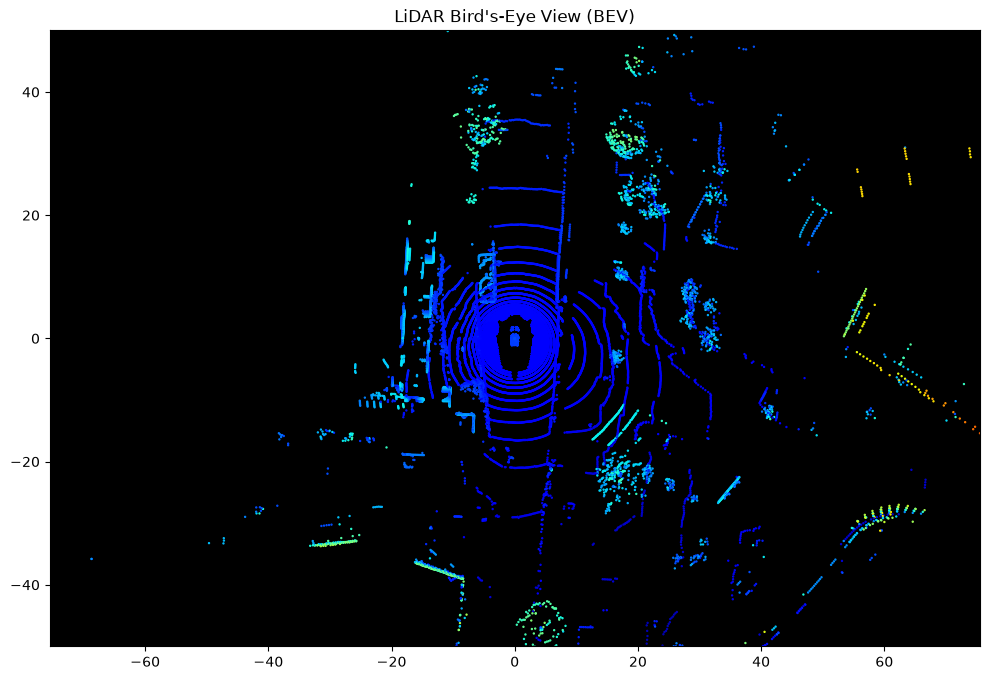

In [139]:
plt.figure(figsize=(12, 8))

# Plot top-down (X and Y coordinates)
# Colorize by Z (height) to emphasize cars vs. the flat road
plt.scatter(xyz[:, 0], xyz[:, 1], c=xyz[:, 2], cmap='jet', s=0.5)

plt.title("LiDAR Bird's-Eye View (BEV)")
plt.axis('equal')
plt.xlim(-50, 50)  # Limit range to 50 meters around vehicle
plt.ylim(-50, 50)
plt.gca().set_facecolor('black')  # Black background makes laser points pop
plt.show()

### plotly

In [195]:
stride = 1
sub_xyz = xyz[::stride]
sub_int = intensity[::stride]

fig = go.Figure(
    data=[
        go.Scatter3d(
            x=sub_xyz[:, 0], y=sub_xyz[:, 1], z=sub_xyz[:, 2],
            mode='markers',
            marker=dict(
                size=1,
                color=sub_int,      # Color code by sensor intensity reflections
                colorscale='Viridis',
                opacity=0.8
            )
        )
    ]
)

# Tweak layout for spatial proportions
fig.update_layout(scene=dict(aspectmode='data'), margin=dict(r=0, l=0, b=0, t=0))

fig.write_html('./outputs/plots/tmp.html', auto_open=True)

NameError: name 'xyz' is not defined

## Transform manually: 

- take a few sample_annotation boxes (given in the global frame) and transform them into the LiDAR sensor frame yourself, composing:
global → ego using ego_pose (translation + rotation, per timestamp)
ego → sensor using calibrated_sensor (translation + rotation, per sensor)

---
---


A `sample_annotation` is **one 3D bounding box around one object at one keyframe** — the fundamental ground-truth unit. Here's what's actually in the record, grouped by what each part does:

**Geometry — the box itself (what the model predicts):**
- **`translation`** — `[x, y, z]`, the box center in the **global frame**, in meters. (Global is why Milestone 1 has you transform these into the LiDAR frame.)
- **`size`** — `[width, length, height]`, in meters. Note the order — w, l, h — it trips people up when comparing to model outputs that use l, w, h.
- **`rotation`** — orientation as a **quaternion** `[w, x, y, z]`. In practice you mostly care about yaw (heading around the vertical axis) extracted from it; nuScenes boxes have full 3D orientation but objects are effectively yaw-only on the ground plane.

Together these seven-ish numbers (center 3 + size 3 + yaw 1) are exactly the 3D box a detector regresses. This is the "answer key."

**Identity and linkage (the tokens):**
- **`token`** — this annotation's own ID.
- **`sample_token`** — which keyframe it belongs to (the parent `sample`).
- **`instance_token`** — which unique physical object this is. **This is the key one for the instance-vs-annotation distinction**: all annotations of the same car across the scene share one `instance_token`. It's what makes tracking possible (911 instances → 18538 annotations in mini).
- **`prev` / `next`** — tokens linking this box to the same object's box in the previous/next keyframe. A per-object temporal chain, parallel to the sample chain. Empty string at the object's first/last appearance.

**Semantics — what it is:**
- The **category** (car, pedestrian, truck, traffic_cone, etc.) — technically reached via the instance's `category_token`, but effectively "what class is this box." This is the classification label; it's what drives the color-coding you saw in your CAM_FRONT render.
- **`attribute_tokens`** — state flags: `vehicle.moving` vs `vehicle.parked` vs `vehicle.stopped`, `pedestrian.moving` vs `standing`, `cycle.with_rider`, etc. A list (can be empty). The **mAAE** metric scores these.
- **`visibility_token`** — which visibility bin (roughly 0–40 / 40–60 / 60–80 / 80–100% visible across the camera views). Useful for filtering — e.g. you might exclude near-invisible boxes when analyzing failures.

**Annotation quality / provenance:**
- **`num_lidar_pts`** — how many LiDAR points fell inside this box. **Very useful practically**: a box with 2 LiDAR points is barely observed (far away or heavily occluded), and the standard nuScenes eval / training often filters boxes with too few points. When you do failure analysis in Milestone 5, this is how you separate "model missed an easy object" from "model missed something with 3 points."
- **`num_radar_pts`** — same, for radar returns.

A few things worth flagging because they're easy to get wrong:

- **Coordinates are global, not sensor.** The single most important thing to remember: `translation`/`rotation` are in the world frame. Your model works in the LiDAR/BEV frame, so the transform is mandatory — it's not optional preprocessing, it's the thing that makes labels usable. That's the entire point of the Milestone 1 exercise.
- **Velocity isn't stored — it's derived.** There's no velocity field in the annotation. nuScenes computes an object's velocity from its `translation` across `prev`/`next` annotations (finite difference over time). The devkit has `nusc.box_velocity(annotation_token)` for this. The **mAVE** metric depends on it, and it's why the temporal linking exists.
- **The devkit assembles the convenient form for you.** Rather than manually joining annotation → instance → category, `nusc.get_sample_data(...)` and `nusc.get_box(...)` return ready-made `Box` objects with center, size, orientation, and category name already resolved and (optionally) already transformed into a sensor frame. You'll hand-roll the transform *once* in Milestone 1 to understand it, then let the devkit do it thereafter.

So the mental model: a `sample_annotation` is **the labeled 3D box (geometry) + which object it is (instance linkage) + what it is (category/attributes) + how well it was observed (lidar/radar point counts)** — everything needed to serve as ground truth for detection, and, through the instance and prev/next links, for tracking and velocity too.


---

- **Get ego_pose for an annotation**
    - In a sample the sensor streams are captured at slightly different timestamps, so they each have their own unique ego_pose.
 
    - Because a sample_annotation is a single, abstract 3D box tied to the overall sample checkpoint, it does not have its own independent ego pose.
 
    - Instead, the annotation's coordinates are locked to the **master sensor clock of that sample**. In nuScenes, **the master clock is always the LiDAR (LIDAR_TOP)**.
 

- **ego_pose**

    - `ego coordinate system`: We have a **catresian coordinate system attached to the ego** (center of the back axel) where x points right, y points forward, and z points up.

    - `translation`: **x, y, and z of the ego (center of the back axel)** in the global coordinate system
 
    - `rotation`: The rotation is the **rotation of this ego coordinate system wrt the global coordinate system**.
 
- **quaternion rotation**

    - To get the **rotation of object 1 wrt object 2**, you take the inverse of object 2's quaternion ($q_2^{-1}$) and multiply it by object 1's quaternion ($q_1$) using the Hamilton product.
$$q_{\text{relative}} = q_2^{-1} \otimes q_1$$


---

- **Transformation Order**

    - When moving from local to a parent frame, you must **rotate first**, and **then translate**.
        - Example: like from `sensor to ego` frame
 
    - When moving from a parent to a local frame, you must **translate first**, and **then rotate**.
        - Example: like from `global to ego` frame
     
- **Orders**
    - Moving from **local to parent** frame:
        1. `rotated = points @ R_local.T`
        2. `points_final = rotated + local_origin`
    - Moving from **parent to local** frame:
        1. `translated = points - local_origin`
        2. `points_final = translated @ R_local`
     

---

- **Camera Coordinate**
    - The camera coordinate system's origin is at the camera's optical center (roughly, the lens)
        - z pointing forward along the optical axis (the direction the camera looks / depth into the scene)
        - x pointing right
        - y pointing down.
 
- **Camera Projection**:
    - camera intrinsics:
        - K = [[fx, 0, cx],
     [0, fy, cy],
     [0,  0,  1]]
    
    - K @ p = [fx·x + cx·z,  fy·y + cy·z,  z]
 
        - Call that [u', v', w']; The third component is just z
 
    - u = u' / w' = fx·(x/z) + cx
 
    - v = v' / w' = fy·(y/z) + cy
 
    - **That final divide by z is the projection** — the perspective part, the thing that makes far objects small.
 
    - Any point with z ≤ 0 is behind the camera; dividing by it produces garbage (or a mirrored ghost point). Drop those before the division, not after.
 

---

- **Move Annotation Box to LiDAR Frame**
    1. We find the corners in the box frame
 
    2. We move those points from the box frame to global frame
 
    3. we move them to ego frame
 
    4. we move them to the lidar frmae
 


---

### look into later

- yaw?


### Manual, scipy

In [ ]:
from scipy.spatial.transform import Rotation as R

In [303]:
ann_token = nusc.sample[0]["anns"][0]
ann = nusc.get("sample_annotation", ann_token)

ann_t_g = np.array(ann["translation"])
ann_q_g = ann["rotation"]

sample = nusc.get("sample", ann["sample_token"])
lidar_token = sample["data"]["LIDAR_TOP"]
lidar = nusc.get("sample_data", lidar_token)
ego_pose = nusc.get("ego_pose", lidar["ego_pose_token"])

ego_t = np.array(ego_pose["translation"])
ego_q = ego_pose["rotation"]


# Convert quaternions to SciPy format [x, y, z, w]
ann_q_g_scp = [ann_q_g[1], ann_q_g[2], ann_q_g[3], ann_q_g[0]]
ego_q_scp = [ego_q[1], ego_q[2], ego_q[3], ego_q[0]]

r_ego = R.from_quat(ego_q_scp)

ann_treanslated = ann_t_g - ego_t
ann_t_e = r_ego.inv().apply(ann_treanslated)

r_ann = R.from_quat(ann_q_g_scp)

r_ann_q_e = r_ego.inv() * r_ann
ann_q_e = r_ann_q_e.as_quat()
ann_q_e = [ann_q_e[-1], ann_q_e[0], ann_q_e[1], ann_q_e[2]]

In [304]:
ann_t_e

array([ 60.49822359, -18.28904132,   1.05895171])

In [305]:
ann_q_e

[0.712470187624882,
 0.0038283281031140834,
 -0.011288011373492684,
 0.7016011377192404]

### Manual, pyquaternion

In [ ]:
from pyquaternion import Quaternion

In [356]:
ann_token = nusc.sample[0]["anns"][0]
ann = nusc.get("sample_annotation", ann_token)

ann_t_g = np.array(ann["translation"])
ann_q_g = Quaternion(ann["rotation"])

sample = nusc.get("sample", ann["sample_token"])
lidar_token = sample["data"]["LIDAR_TOP"]
lidar = nusc.get("sample_data", lidar_token)
ego_pose = nusc.get("ego_pose", lidar["ego_pose_token"])

ego_t = np.array(ego_pose["translation"])
ego_q = Quaternion(ego_pose["rotation"])

ann_translated = ann_t_g - ego_t
ann_t_e = ego_q.inverse.rotate(ann_translated)

ann_q_e = ego_q.inverse * ann_q_g
# ann_q_ego_np = ann_q_ego.elements

In [357]:
ann_t_e

array([ 60.49822359, -18.28904132,   1.05895171])

In [358]:
ann_q_e

Quaternion(0.7124701876248815, 0.0038283281031140813, -0.011288011373492677, 0.7016011377192398)

In [359]:
ann_q_e.elements

array([ 0.71247019,  0.00382833, -0.01128801,  0.70160114])

#### from ego --> sensor

In [360]:
# ann_t_e
# ann_q_e

cal_sens = nusc.get("calibrated_sensor", lidar["calibrated_sensor_token"])
sens_t = np.array(cal_sens["translation"])
sens_q = Quaternion(cal_sens["rotation"])

translated_center = ann_t_e - sens_t
ann_t_s = sens_q.inverse.rotate(translated_center)

ann_q_s = sens_q.inverse * ann_q_e

In [361]:
ann_t_s

array([18.414385  , 59.51602513,  0.76963457])

In [362]:
ann_q_s

Quaternion(0.008592156865872391, 0.00783861100639374, -0.01742570265551263, 0.99978051386534)

### Use NuScenes

In [363]:
ann_token = nusc.sample[0]["anns"][0]
ann = nusc.get("sample_annotation", ann_token)

sample = nusc.get("sample", ann["sample_token"])
lidar_token = sample["data"]["LIDAR_TOP"]
lidar = nusc.get("sample_data", lidar_token)
ego_pose = nusc.get("ego_pose", lidar["ego_pose_token"])

ego_t = np.array(ego_pose["translation"])
ego_q = Quaternion(ego_pose["rotation"])

box = nusc.get_box(ann_token)


box.translate(-ego_t)
# When you call box.rotate(ego_q.inverse), the NuScenes Box class internally updates
# both geometric properties of the box at the same time. ** look at the source code**
box.rotate(ego_q.inverse)

ann_t_e = box.center  # NumPy array [x, y, z]
ann_q_e = box.orientation  # PyQuaternion object [w, x, y, z]

In [321]:
ann_t_e

array([-38.04793493, -50.47137918,   0.8       ])

In [317]:
ann_q_e

Quaternion(0.7124701876248815, 0.0038283281031140813, -0.011288011373492677, 0.7016011377192398)

In [318]:
ann_q_e.elements

array([ 0.71247019,  0.00382833, -0.01128801,  0.70160114])

In [364]:
cal_sens = nusc.get("calibrated_sensor", lidar["calibrated_sensor_token"])
sens_t = np.array(cal_sens["translation"])
sens_q = Quaternion(cal_sens["rotation"])

box = nusc.get_box(ann_token)

box.translate(-ego_t)
box.rotate(ego_q.inverse)

box.translate(-sens_t)
box.rotate(sens_q.inverse)

In [365]:
box.center

array([18.414385  , 59.51602513,  0.76963457])

In [366]:
box.orientation

Quaternion(0.008592156865872391, 0.00783861100639374, -0.01742570265551263, 0.99978051386534)

In [367]:
box.center - ann_t_s

array([-1.42108547e-14,  1.42108547e-14,  2.22044605e-16])

In [369]:
box.orientation == ann_q_s

True

## Project LiDAR into Camera Image

In [5]:
from nuscenes.utils.data_classes import LidarPointCloud
from pathlib import Path
import numpy as np
from pyquaternion import Quaternion

In [13]:
sample = nusc.sample[1]

lidar_token = sample["data"]["LIDAR_TOP"]
cam_token = sample["data"]["CAM_FRONT"]

lidar = nusc.get("sample_data", lidar_token)
cam = nusc.get("sample_data", cam_token)

In [14]:
file_base_path = Path("../data/nuscenes/")
lidar_file_path = file_base_path / lidar["filename"]

pc = np.fromfile(lidar_file_path, dtype=np.float32)
pc = pc.reshape((-1, 5))
pc1 = pc[0, :-2]

In [15]:
# from sensor to ego
cal_sens = nusc.get("calibrated_sensor", lidar["calibrated_sensor_token"])
sens_t = np.array(cal_sens["translation"])
sens_q = Quaternion(cal_sens["rotation"])

pc1_rotated = sens_q.rotate(pc1)
pc1_e = sens_t + pc1_rotated


# from ego to glob
ego_pose = nusc.get("ego_pose", lidar["ego_pose_token"])
ego_t = np.array(ego_pose["translation"])
ego_q = Quaternion(ego_pose["rotation"])

pc1_rotated = ego_q.rotate(pc1_e)
pc1_g = ego_t + pc1_rotated

In [16]:
pc1_g

array([ 4.12513983e+02,  1.17517070e+03, -7.63288978e-02])

In [21]:
lidar_data = nusc.get("sample_data", lidar_token)

pc_2 = LidarPointCloud.from_file(nusc.get_sample_data_path(lidar_token))
calibrated_sensor = nusc.get("calibrated_sensor", lidar_data["calibrated_sensor_token"])
ego_pose = nusc.get("ego_pose", lidar_data["ego_pose_token"])

pc_2.rotate(Quaternion(calibrated_sensor["rotation"]).rotation_matrix)
pc_2.translate(np.array(calibrated_sensor["translation"]))

pc_2.rotate(Quaternion(ego_pose["rotation"]).rotation_matrix)
pc_2.translate(np.array(ego_pose["translation"]))

global_points = pc_2.points[:3, :].T  # Sliced to get just the X, Y, Z coordinates

In [22]:
global_points[0, :] - pc1_g

array([2.43160749e-05, 7.22741936e-05, 1.67555500e-08])

In [23]:
# Now trying to take the point back to the camera sensor frame
ego_pose = nusc.get("ego_pose", cam["ego_pose_token"])
cal_sens = nusc.get("calibrated_sensor", cam["calibrated_sensor_token"])

ego_t = np.array(ego_pose["translation"])
ego_q = Quaternion(ego_pose["rotation"])

sens_t = np.array(cal_sens["translation"])
sens_q = Quaternion(cal_sens["rotation"])

translated = pc1_g - ego_t
pc1_e = ego_q.inverse.rotate(translated)

translated = pc1_e - sens_t
pc1_s = sens_q.inverse.rotate(translated)

In [24]:
pc1_s

array([-3.10799956,  1.5004467 , -0.88871821])

## Camera Projection

In [7]:
from nuscenes.utils.data_classes import LidarPointCloud
from pathlib import Path
import numpy as np
from pyquaternion import Quaternion
import matplotlib.image as mpimg
import matplotlib.patches as patches

In [56]:
# z in negative and this point should be filtered. Do your calculations on all the lidar points before moving forward
sample = nusc.sample[1]

lidar_token = sample["data"]["LIDAR_TOP"]
cam_token = sample["data"]["CAM_FRONT"]

lidar = nusc.get("sample_data", lidar_token)
cam = nusc.get("sample_data", cam_token)

file_base_path = Path("../data/nuscenes/")
lidar_file_path = file_base_path / lidar["filename"]

pc = np.fromfile(lidar_file_path, dtype=np.float32)
pc = pc.reshape((-1, 5))

image_file_path = file_base_path / cam["filename"]
img = mpimg.imread(image_file_path)

In [57]:
pc.shape, img.shape

((34720, 5), (900, 1600, 3))

In [58]:
cal_lidar = nusc.get("calibrated_sensor", lidar["calibrated_sensor_token"])
lidar_t = np.array(cal_lidar["translation"])
lidar_q = Quaternion(cal_lidar["rotation"])
lidar_R = lidar_q.rotation_matrix

ego_pose = nusc.get("ego_pose", lidar["ego_pose_token"])
ego_t = np.array(ego_pose["translation"])
ego_q = Quaternion(ego_pose["rotation"])
ego_R = ego_q.rotation_matrix

In [59]:
rotated = pc[:, :3] @ lidar_R.T
pc_e = lidar_t + rotated

rotated = pc_e @ ego_R.T
pc_g = ego_t + rotated

In [60]:
ego_pose = nusc.get("ego_pose", cam["ego_pose_token"])
cal_cam = nusc.get("calibrated_sensor", cam["calibrated_sensor_token"])

ego_t = np.array(ego_pose["translation"])
ego_q = Quaternion(ego_pose["rotation"])
ego_R = ego_q.rotation_matrix

cam_t = np.array(cal_cam["translation"])
cam_q = Quaternion(cal_cam["rotation"])
cam_R = cam_q.rotation_matrix

In [61]:
translated = pc_g - ego_t
pc_e = translated @ ego_R

translated = pc_e - cam_t
pc_c = translated @ cam_R

In [62]:
pc_c

array([[ -3.10799956,   1.5004467 ,  -0.88871821],
       [ -3.26876194,   1.49286406,  -0.88593013],
       [ -3.44999005,   1.48951852,  -0.88350449],
       ...,
       [-18.11446456,  -3.02084587,  -0.31098351],
       [-15.50063383,  -3.00227899,  -0.3179035 ],
       [-18.12040231,  -3.8918237 ,  -0.28155659]])

In [63]:
# Cull points filter (behind the camera)
front = pc_c[:, 2] > 0
pc_c = pc_c[front]
uvz = pc_c @ np.array(cal_cam["camera_intrinsic"]).T
# devide by depth
uvz = uvz / uvz[:, -1:]
pixels = uvz[:, :-1]
pixels.shape, pc_c.shape

((12454, 2), (12454, 3))

In [64]:
height, width = img.shape[:2]
u = pixels[:, 0]
v = pixels[:, 1]
# Clip to image bounds
in_bounds = (u >= 0) & (u < width) & (v >= 0) & (v < height)
pixels_visible = pixels[in_bounds]
print(pixels_visible.shape)

pc_visible = pc_c[in_bounds]
pc_visible.shape

(2977, 2)


(2977, 3)

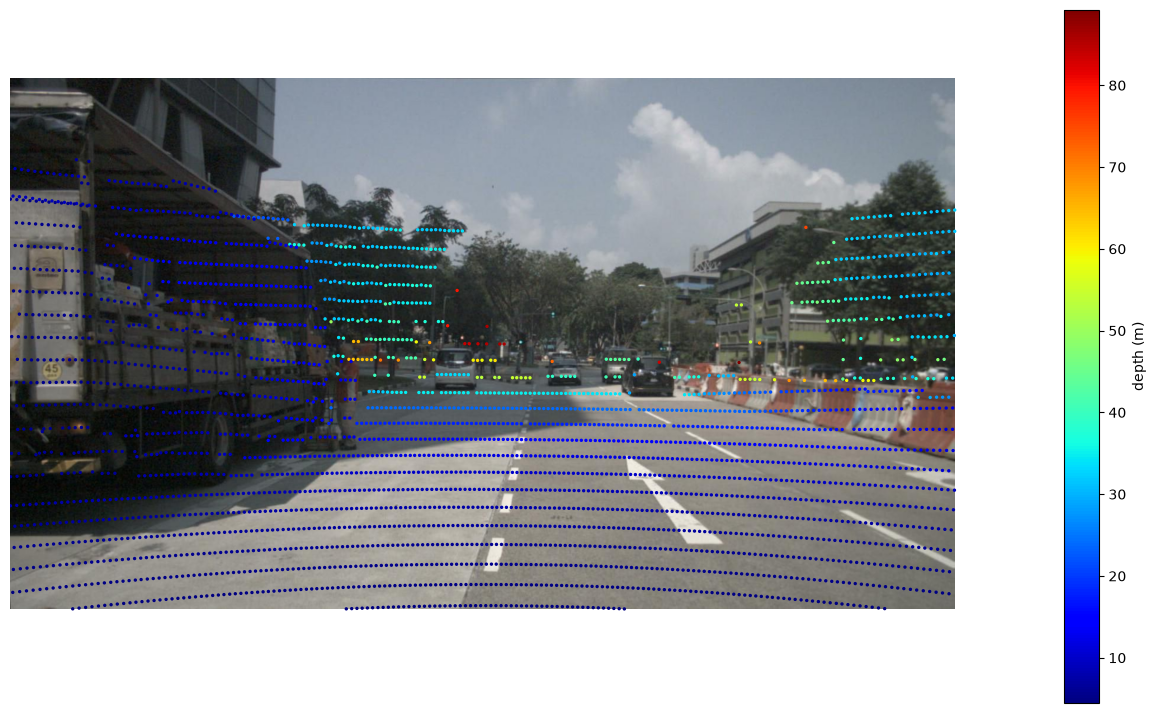

In [65]:
fig, ax = plt.subplots(figsize=(16, 9))
ax.imshow(img)                                    # the RGB photo underneath

sc = ax.scatter(
    pixels_visible[:, 0],                         # u -> horizontal
    pixels_visible[:, 1],                         # v -> vertical
    c=pc_visible[:, 2],                             # color by distance
    s=2,                                          # small dots
    cmap='jet',                                   # depth colormap
)

ax.axis('off')
plt.colorbar(sc, ax=ax, label='depth (m)')
# plt.savefig('./outputs/lidar_on_cam.png', dpi=120, bbox_inches='tight')
plt.show()

## Rendering a BEV / top-down view

In [196]:
sample = nusc.sample[1]

lidar_token = sample["data"]["LIDAR_TOP"]
lidar = nusc.get("sample_data", lidar_token)

ego_pose = nusc.get("ego_pose", lidar["ego_pose_token"])
cal_lidar = nusc.get("calibrated_sensor", lidar["calibrated_sensor_token"])

ann_token = sample["anns"][7]
ann = nusc.get("sample_annotation", ann_token)

In [197]:
file_base_path = Path("../data/nuscenes/")
lidar_file_path = file_base_path / lidar["filename"]

pc = np.fromfile(lidar_file_path, dtype=np.float32)
pc = pc.reshape((-1, 5))
pc = pc[:, :3]

In [198]:
ann_s = np.array(ann["size"])
w, l, h = ann_s / 2

# nuScenes box convention is x = length (forward), y = width, z = height
corners_a = np.array(
    [
        [l, w,  h], [l, -w, h], [-l, -w, h], [-l, w, h],   # top face
        [l, w, -h], [l, -w, -h], [-l, -w, -h], [-l, w, -h],   # bottom face
    ]
)

In [199]:
ann_t = np.array(ann["translation"])
ann_q = Quaternion(ann["rotation"])
ann_R = ann_q.rotation_matrix

ego_t = np.array(ego_pose["translation"])
ego_q = Quaternion(ego_pose["rotation"])
ego_R = ego_q.rotation_matrix

lidar_t = np.array(cal_lidar["translation"])
lidar_q = Quaternion(cal_lidar["rotation"])
lidar_R = lidar_q.rotation_matrix

In [200]:
# local to parent
rotated = corners_a @ ann_R.T
corners_g = rotated + ann_t

# parent to local
translated = corners_g - ego_t
corners_e = translated @ ego_R

translated = corners_e - lidar_t
corners_l = translated @ lidar_R

corners_bottom = corners_l[4:, :2]

In [205]:
import numpy as np
import plotly.graph_objects as go

# 1. Initialize the figure
fig = go.Figure()

# 2. Add the Lidar points scatter trace
fig.add_trace(
    go.Scatter(
        x=pc[:, 0],
        y=pc[:, 1],
        mode="markers",
        marker=dict(
            size=2,
            color=pc[:, 2],  # Color by height/depth (optional, matches your commented cmap)
            colorscale="Jet",
            showscale=False,
        ),
        name="Lidar Points",
    )
)

# 3. Close the bounding box loop by appending the first point to the end
box_x = np.append(corners_bottom[:, 0], corners_bottom[0, 0])
box_y = np.append(corners_bottom[:, 1], corners_bottom[0, 1])

# 4. Add the Bounding Box trace
fig.add_trace(
    go.Scatter(
        x=box_x,
        y=box_y,
        mode="lines",
        line=dict(color="red", width=2),
        name="Bounding Box",
    )
)

# 5. Style the layout for a sleek black background and 1:1 aspect ratio
fig.update_layout(
    template="plotly_dark",  # Automatically handles dark mode styles
    plot_bgcolor="black",
    paper_bgcolor="black",
    width=1000,
    height=800,
    showlegend=False,
    xaxis=dict(
        showgrid=False,
        zeroline=False,
        showticklabels=False,  # Equivalent to ax.axis('off')
        scaleanchor="y",  # CRITICAL: Forces 1:1 pixel aspect ratio
        scaleratio=1,
    ),
    yaxis=dict(
        showgrid=False,
        zeroline=False,
        showticklabels=False,
    ),
)

# Render the interactive plot
# fig.show()
fig.write_html('./outputs/plots/tmp.html', auto_open=True)

In [ ]:
fig, ax = plt.subplots(figsize=(16, 9))
sc = ax.scatter(
    pc[:, 0],
    pc[:, 1],
    # c=pc[:, 2],
    s=2,
    # cmap='jet',
)

rect = patches.Polygon(corners_bottom, closed=True, edgecolor='r', facecolor='none', linewidth=2)
ax.add_patch(rect)

plt.gca().set_facecolor('black')
plt.show()

Loop over all annotations at once

In [178]:
# --- shared once per frame (hoist OUT of the loop) ---
ego_t, ego_R = np.array(ego_pose["translation"]), Quaternion(ego_pose["rotation"]).rotation_matrix
lidar_t, lidar_R = np.array(cal_lidar["translation"]), Quaternion(cal_lidar["rotation"]).rotation_matrix

base_corners = np.array([   # unit box corner template, reused each iteration
    [ 1,  1,  1], [ 1, -1,  1], [-1, -1,  1], [-1,  1,  1],
    [ 1,  1, -1], [ 1, -1, -1], [-1, -1, -1], [-1,  1, -1],
])

boxes_lidar = []
for ann_token in sample["anns"]:
    ann = nusc.get("sample_annotation", ann_token)

    # per-box (varies every iteration)
    l, w, h = np.array(ann["size"])[[1, 0, 2]] / 2   # size is [w,l,h]; want x=l, y=w, z=h
    corners = base_corners * np.array([l, w, h])      # scale template -> (8,3)
    ann_R = Quaternion(ann["rotation"]).rotation_matrix

    # box-local -> global -> ego -> lidar  (all vectorized over the 8 corners)
    c = corners @ ann_R.T + np.array(ann["translation"])   # -> global
    c = (c - ego_t)   @ ego_R                               # -> ego
    c = (c - lidar_t) @ lidar_R                             # -> lidar
    boxes_lidar.append(c)

boxes_lidar = np.array(boxes_lidar)   # (num_boxes, 8, 3)

In [180]:
# 1. Figure
fig = go.Figure()

# 2. Lidar points (unchanged)
fig.add_trace(
    go.Scatter(
        x=pc[:, 0], y=pc[:, 1],
        mode="markers",
        marker=dict(size=2, color=pc[:, 2], colorscale="Jet", showscale=False),
        name="Lidar Points",
    )
)

# 3+4. One trace per box — bottom face, closed
for i, box in enumerate(boxes_lidar):          # box: (8, 3)
    bottom = box[4:, :2]                        # 4 bottom corners, x-y
    box_x = np.append(bottom[:, 0], bottom[0, 0])   # close the loop
    box_y = np.append(bottom[:, 1], bottom[0, 1])
    fig.add_trace(
        go.Scatter(
            x=box_x, y=box_y,
            mode="lines",
            line=dict(color="red", width=2),
            name=f"box {i}",
            showlegend=False,
        )
    )

# 5. Layout (unchanged)
fig.update_layout(
    template="plotly_dark", plot_bgcolor="black", paper_bgcolor="black",
    width=1000, height=800, showlegend=False,
    xaxis=dict(showgrid=False, zeroline=False, showticklabels=False,
               scaleanchor="y", scaleratio=1),
    yaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
)
fig.write_html('./outputs/plots/tmp.html', auto_open=True)

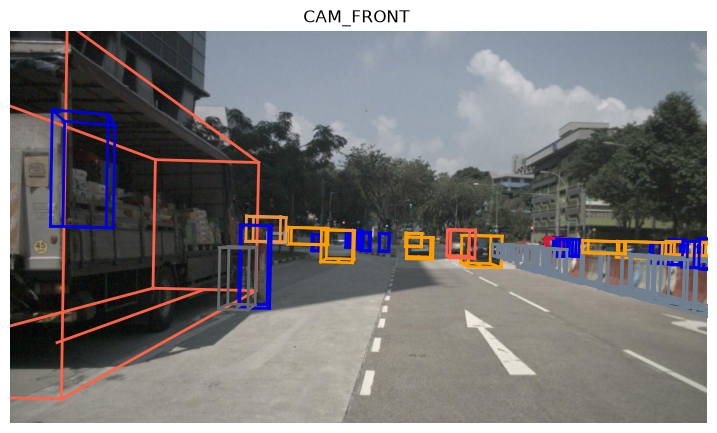

In [181]:
nusc.render_sample_data(sample['data']['CAM_FRONT'])

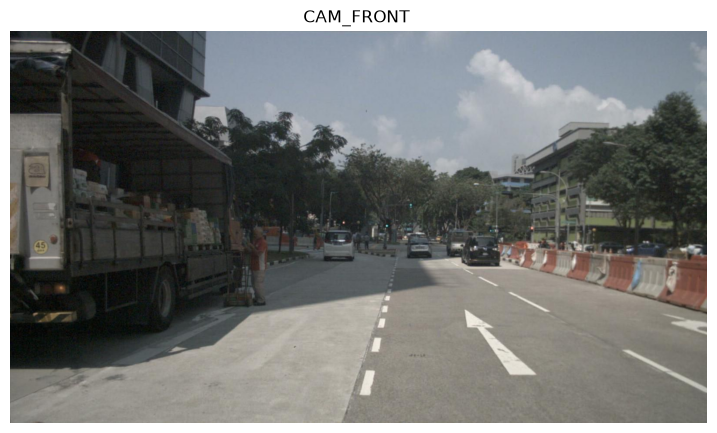

In [183]:
nusc.render_sample_data(sample['data']['CAM_FRONT'], with_anns=False)

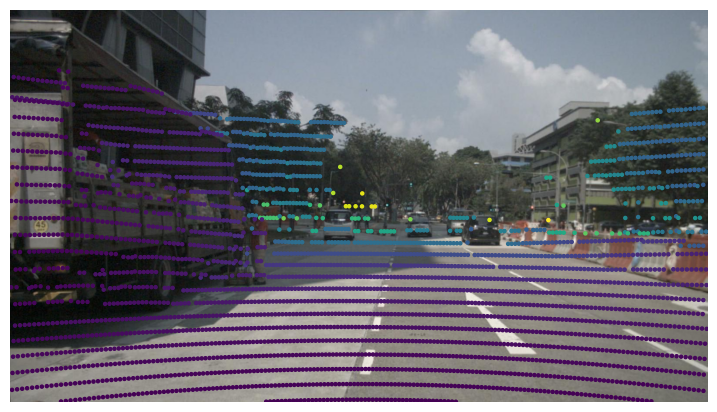

In [182]:
nusc.render_pointcloud_in_image(
    sample['token'],
    pointsensor_channel='LIDAR_TOP',
    camera_channel='CAM_FRONT',
    render_intensity=False,
    out_path='./outputs/cam_front_lidar.png',
)

## Accumulate 10 LiDAR sweeps and (motion-compensate them)